In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fixer la graine pour avoir toujours les mêmes résultats
np.random.seed(42)

# Créer 50 personnes avec des données aléatoires
n = 50
data = {
    'age': np.random.randint(22, 60, n),           # Âge entre 22 et 60 ans
    'experience': np.random.randint(1, 35, n),     # Expérience entre 1 et 35 ans
    'income': np.random.randint(2000, 10000, n).astype(float)  # Salaire entre 2000 et 10000
}

df = pd.DataFrame(data)

# Supprimer 8 salaires au hasard (les rendre manquants)
df.loc[np.random.choice(df.index, 8, replace=False), 'income'] = np.nan

# Afficher les 10 premières lignes
print(df.head(10))

   age  experience  income
0   50           4  2502.0
1   36          29  8910.0
2   29          18  6493.0
3   42          26     NaN
4   40          34  8938.0
5   44          10  6488.0
6   32          14  2206.0
7   32          31  7134.0
8   45          15  7977.0
9   57           8     NaN


In [13]:
# Compter les valeurs manquantes
print("\nNombre de valeurs manquantes :")
print(df.isnull().sum())

# Pourcentage de valeurs manquantes
print("\nPourcentage de valeurs manquantes :")
print(df.isnull().sum() / len(df) * 100)


Nombre de valeurs manquantes :
age           0
experience    0
income        8
dtype: int64

Pourcentage de valeurs manquantes :
age            0.0
experience     0.0
income        16.0
dtype: float64


In [14]:
# Séparer les données complètes et incomplètes
df_train = df[df['income'].notna()]  # Lignes AVEC salaire
df_test = df[df['income'].isna()]    # Lignes SANS salaire

# Préparer X (âge + expérience) et y (salaire)
X_train = df_train[['age', 'experience']].values
y_train = df_train['income'].values

# Ajouter une colonne de 1 pour le biais (intercept)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]

# FORMULE MAGIQUE : β = (X^T X)^-1 X^T y
X_transpose = X_train.T
beta = np.linalg.inv(X_transpose @ X_train) @ X_transpose @ y_train

print(f"Coefficients trouvés : {beta}")

Coefficients trouvés : [5432.96858472   15.20278558   21.68637192]


In [15]:
# ========================================
# ÉTAPE 4 : Compléter les données manquantes
# ========================================

# Préparer les données de test
X_test = df_test[['age', 'experience']].values
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# Prédire les salaires manquants
predictions = X_test @ beta

print(f"Valeurs prédites : {predictions}")

# Remplir les valeurs manquantes
df.loc[df['income'].isna(), 'income'] = predictions

# Vérification
print("\nVérification - valeurs manquantes restantes :")
print(df.isnull().sum())

# Sauvegarder le DataFrame complété
df_completed = df.copy()
print("\n✅ DataFrame complété et sauvegardé dans df_completed !")

Valeurs prédites : [6635.3312491  6473.01833817 6728.78357548 5956.34688078 6227.31490367
 6420.25663809 6350.94954887 6869.85661915]

Vérification - valeurs manquantes restantes :
age           0
experience    0
income        0
dtype: int64

✅ DataFrame complété et sauvegardé dans df_completed !


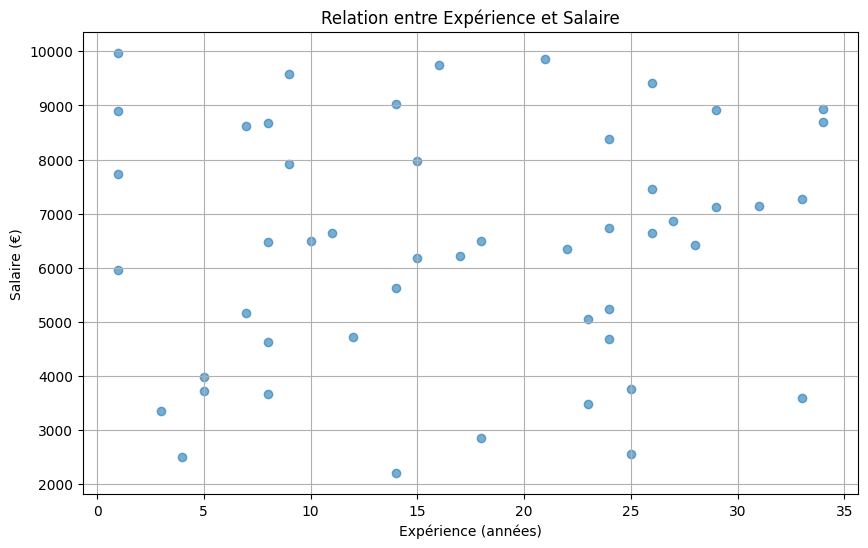

In [16]:
# Graphique : Expérience vs Salaire
plt.figure(figsize=(10, 6))
plt.scatter(df['experience'], df['income'], alpha=0.6)
plt.xlabel('Expérience (années)')
plt.ylabel('Salaire (€)')
plt.title('Relation entre Expérience et Salaire')
plt.grid(True)
plt.show()

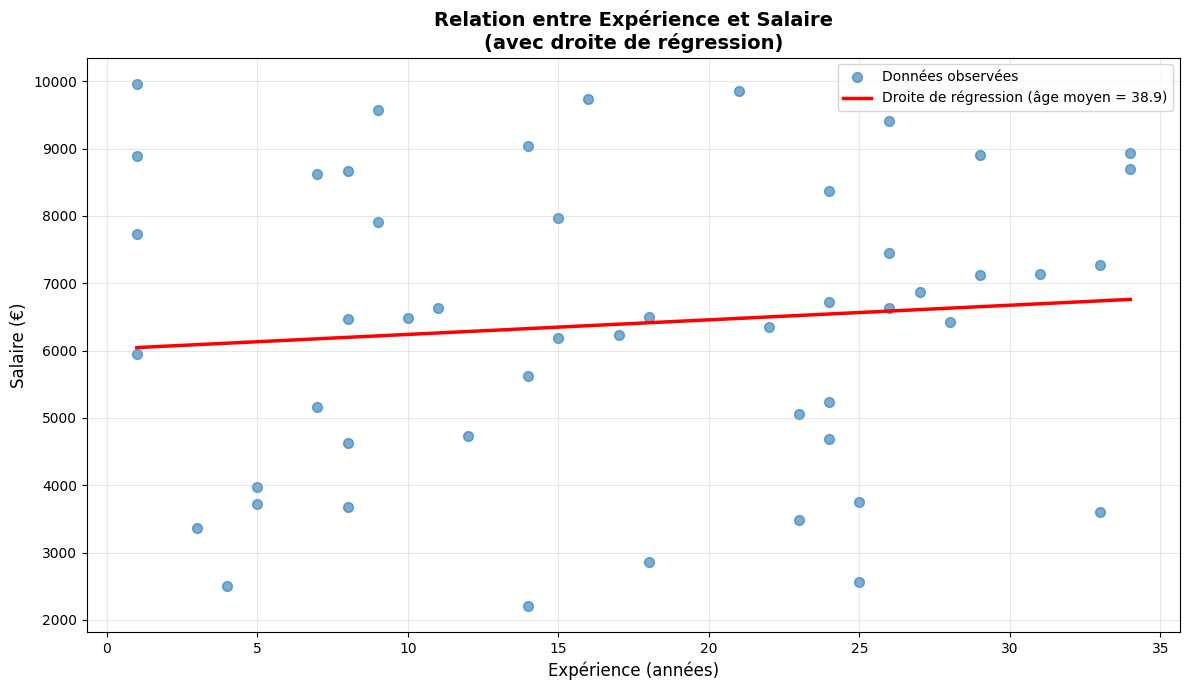


ÉQUATION DE RÉGRESSION
Salaire = 5432.97 + 15.20 × Âge + 21.69 × Expérience


In [17]:
# ========================================
# ÉTAPE 5 : Visualisation avec droite de régression
# ========================================

import matplotlib.pyplot as plt

# Graphique : Expérience vs Salaire avec droite de régression
plt.figure(figsize=(12, 7))

# 1. Tracer les points
plt.scatter(df_completed['experience'], df_completed['income'], 
            alpha=0.6, s=50, label='Données observées')

# 2. Calculer la droite de régression
# On prend l'âge moyen pour la prédiction
age_mean = df_completed['age'].mean()

# Créer une plage de valeurs d'expérience (de 0 à 35 ans)
experience_range = np.linspace(df_completed['experience'].min(), 
                               df_completed['experience'].max(), 
                               100)

# Construire X pour la droite : [1, age_moyen, experience]
X_line = np.c_[np.ones(100), 
               np.full(100, age_mean), 
               experience_range]

# Calculer les prédictions de salaire
y_line = X_line @ beta

# 3. Tracer la droite de régression
plt.plot(experience_range, y_line, 
         color='red', linewidth=2.5, 
         label=f'Droite de régression (âge moyen = {age_mean:.1f})')

# 4. Mise en forme du graphique
plt.xlabel('Expérience (années)', fontsize=12)
plt.ylabel('Salaire (€)', fontsize=12)
plt.title('Relation entre Expérience et Salaire\n(avec droite de régression)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher l'équation de régression
print("\n" + "="*50)
print("ÉQUATION DE RÉGRESSION")
print("="*50)
print(f"Salaire = {beta[0]:.2f} + {beta[1]:.2f} × Âge + {beta[2]:.2f} × Expérience")
print("="*50)

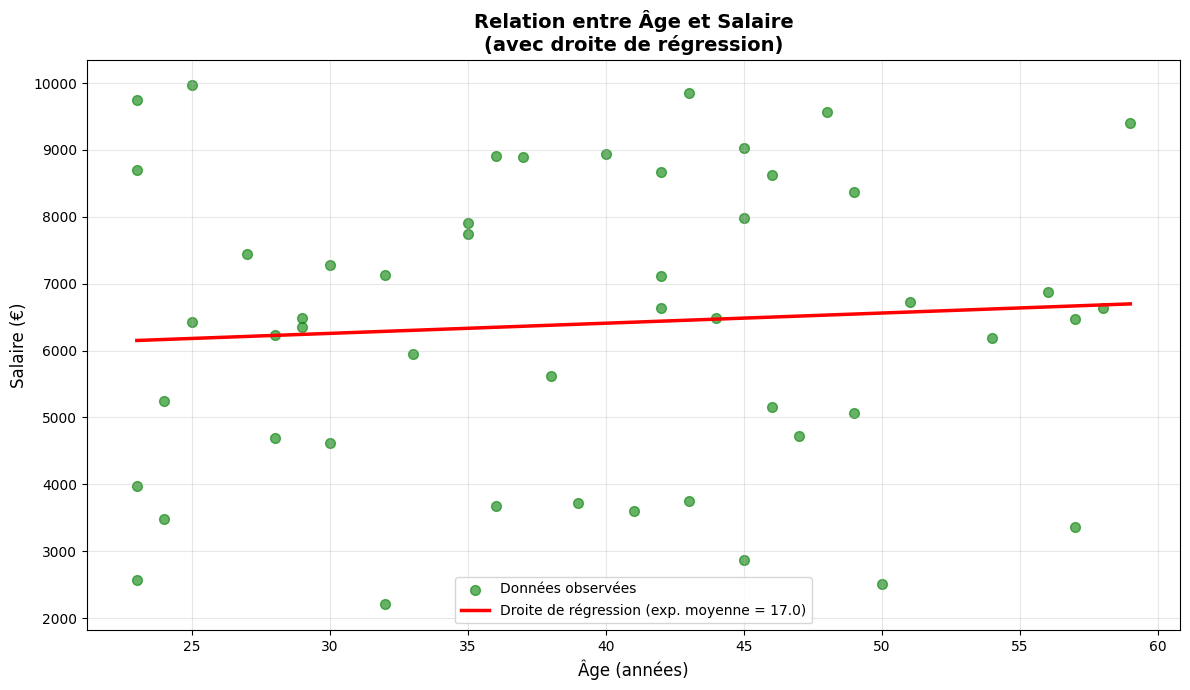

In [18]:
# Graphique : Âge vs Salaire avec droite de régression
plt.figure(figsize=(12, 7))

# 1. Tracer les points
plt.scatter(df_completed['age'], df_completed['income'], 
            alpha=0.6, s=50, color='green', label='Données observées')

# 2. Calculer la droite de régression
experience_mean = df_completed['experience'].mean()

# Créer une plage de valeurs d'âge
age_range = np.linspace(df_completed['age'].min(), 
                        df_completed['age'].max(), 
                        100)

# Construire X pour la droite : [1, age, experience_moyenne]
X_line_age = np.c_[np.ones(100), 
                   age_range, 
                   np.full(100, experience_mean)]

# Calculer les prédictions de salaire
y_line_age = X_line_age @ beta

# 3. Tracer la droite de régression
plt.plot(age_range, y_line_age, 
         color='red', linewidth=2.5, 
         label=f'Droite de régression (exp. moyenne = {experience_mean:.1f})')

# 4. Mise en forme du graphique
plt.xlabel('Âge (années)', fontsize=12)
plt.ylabel('Salaire (€)', fontsize=12)
plt.title('Relation entre Âge et Salaire\n(avec droite de régression)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Questions de Réflexion

### 1. Quels sont les avantages et les limites de l'imputation par régression linéaire ?

**Avantages :**
- Utilise les relations entre variables pour estimer les valeurs manquantes de façon intelligente
- Produit des valeurs cohérentes avec les données existantes
- Simple à implémenter et à interpréter

**Limites :**
- Suppose une relation linéaire entre les variables (pas toujours vrai dans la réalité)
- Peut sous-estimer la variabilité des données (réduit la variance réelle)
- Sensible aux valeurs aberrantes présentes dans les données d'entraînement
- Ne fonctionne pas si les variables explicatives (âge, expérience) ont aussi des valeurs manquantes

---

### 2. Dans quels cas cette méthode pourrait-elle introduire un biais ?

- **Si les données manquantes ne sont pas aléatoires** : par exemple, si seuls les hauts salaires sont systématiquement manquants, le modèle sous-estimera les revenus
- **Si la relation n'est pas linéaire** : si le salaire augmente exponentiellement avec l'expérience, la régression linéaire ne capturera pas bien cette relation
- **Multicolinéarité** : si âge et expérience sont trop corrélés entre eux, les coefficients deviennent instables
- **Échantillon d'entraînement trop petit** : avec peu de données, le modèle risque de mal généraliser aux cas manquants

---

### 3. Quelle autre méthode d'imputation pourrait être utilisée ?

- **Imputation par la moyenne/médiane** : Remplacer par la moyenne de la colonne (simple mais ignore les relations entre variables)
- **KNN (K-Nearest Neighbors)** : Utiliser la moyenne des k observations les plus similaires
- **Imputation multiple (MICE)** : Générer plusieurs imputations pour capturer l'incertitude
- **Forêts aléatoires (Random Forest)** : Pour capturer des relations non-linéaires complexes
- **Hot-deck imputation** : Remplacer par la valeur d'une observation réelle similaire
- **Interpolation** : Si les données ont un ordre temporel ou spatial

---

### 4. Comment étendre cette approche à plusieurs variables explicatives ?

Il suffit d'ajouter plus de colonnes à la matrice X. Par exemple, on pourrait ajouter :

- **Niveau d'éducation** (Bac, Licence, Master, Doctorat) → encodé en variable numérique
- **Secteur d'activité** (IT, Finance, Santé, etc.) → encodé avec one-hot encoding
- **Localisation géographique** (ville, région) → peut avoir un impact fort sur le salaire
- **Taille de l'entreprise** (PME, grande entreprise)
- **Genre, ancienneté dans l'entreprise**, etc.

**La formule reste identique :** β = (X^T X)^-1 X^T y

**Exemple :** Si on ajoute le niveau d'éducation (codé 1 à 5), l'équation devient :

`Salaire = β₀ + β₁×âge + β₂×expérience + β₃×éducation`

Plus on ajoute de variables **pertinentes**, meilleure sera la prédiction. 
